In [6]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [7]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Cameroon/data'

In [8]:
GID2_NAME = 'Nord'
YEAR = '2024'

In [9]:
df = pd.read_csv(f'{base_folder}/{GID2_NAME}/CM_{GID2_NAME}_Timeline_{YEAR}_filled.csv', encoding=enc)

In [10]:
df

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-01,2024,1,2024-01-01,8.221831,12.291199,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,2024-01-01,8.221831,12.291199,15247.0,14544.0,2024-01-01,8.250038,12.250056,2023-12-31,2023-12-31,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-02,2024,1,2024-01-02,8.221831,12.291199,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,2024-01-02,8.221831,12.291199,15410.0,14544.0,2024-01-02,8.250038,12.250056,2024-01-01,2024-01-01,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-03,2024,1,2024-01-03,8.221831,12.291199,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,2024-01-03,8.221831,12.291199,15410.0,14575.0,2024-01-03,8.250038,12.250056,2024-01-02,2024-01-02,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-04,2024,1,2024-01-03,8.221831,12.291199,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,2024-01-04,8.221831,12.291199,15417.0,14521.0,2024-01-04,8.250038,12.250056,2024-01-03,2024-01-03,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-05,2024,1,2024-01-05,8.221831,12.291199,0.364624,-0.014147,-0.393515,0.014147,0.319521,-0.053684,-0.406543,0.053684,0.035530,0.029277,0.015771,0.029277,2024-01-05,8.221831,12.291199,15451.0,14521.0,2024-01-05,8.250038,12.250056,2024-01-04,2024-01-04,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448989,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-27,2024,12,2024-12-26,7.754707,15.552083,0.254978,-0.129234,-0.289343,0.129234,0.295193,-0.097900,-0.305340,0.097900,0.086505,0.056897,0.051174,0.056897,2024-12-27,7.754707,15.552083,15085.0,14441.0,2024-12-27,7.750035,15.550071,2024-12-26,2024-12-26,0.0
1448990,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-28,2024,12,2024-12-28,7.754707,15.552083,0.254978,-0.129234,-0.289343,0.129234,0.295193,-0.097900,-0.305340,0.097900,0.086505,0.056897,0.051174,0.056897,2024-12-28,7.754707,15.552083,15085.0,14476.0,2024-12-28,7.750035,15.550071,2024-12-27,2024-12-27,0.0
1448991,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-29,2024,12,2024-12-29,7.754707,15.552083,0.254978,-0.129234,-0.289343,0.129234,0.295193,-0.097900,-0.305340,0.097900,0.086505,0.056897,0.051174,0.056897,2024-12-29,7.754707,15.552083,15052.0,14453.0,2024-12-29,7.750035,15.550071,2024-12-28,2024-12-28,0.0
1448992,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-30,2024,12,2024-12-30,7.754707,15.552083,0.243278,-0.137847,-0.282271,0.137847,0.280358,-0.107628,-0.296999,0.107628,0.080038,0.052339,0.048076,0.052339,2024-12-30,7.754707,15.552083,15157.0,14453.0,2024-12-30,7.750035,15.550071,2024-12-29,2024-12-29,0.0


In [11]:
df.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-01,2024,1,2024-01-01,8.221831,12.291199,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,2024-01-01,8.221831,12.291199,15247.0,14544.0,2024-01-01,8.250038,12.250056,2023-12-31,2023-12-31,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-02,2024,1,2024-01-02,8.221831,12.291199,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,2024-01-02,8.221831,12.291199,15410.0,14544.0,2024-01-02,8.250038,12.250056,2024-01-01,2024-01-01,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-03,2024,1,2024-01-03,8.221831,12.291199,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,2024-01-03,8.221831,12.291199,15410.0,14575.0,2024-01-03,8.250038,12.250056,2024-01-02,2024-01-02,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-04,2024,1,2024-01-03,8.221831,12.291199,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,2024-01-04,8.221831,12.291199,15417.0,14521.0,2024-01-04,8.250038,12.250056,2024-01-03,2024-01-03,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-05,2024,1,2024-01-05,8.221831,12.291199,0.364624,-0.014147,-0.393515,0.014147,0.319521,-0.053684,-0.406543,0.053684,0.035530,0.029277,0.015771,0.029277,2024-01-05,8.221831,12.291199,15451.0,14521.0,2024-01-05,8.250038,12.250056,2024-01-04,2024-01-04,0.0


In [12]:
date_columns = [col for col in df.columns if 'dt_placement' in col.lower() or 'date' in col.lower()]
print(f"Date columns: {date_columns}")
for col_name in date_columns:
    df[col_name] = pd.to_datetime(df[col_name])

Date columns: ['dt_placement', 'indices_image_date', 'lst_image_date', 'indices_image_date.1', 'dt_placement_minus_1', 'dt_placement_minus_1_avail']


Text(0.5, 1.0, 'Year: 2024')

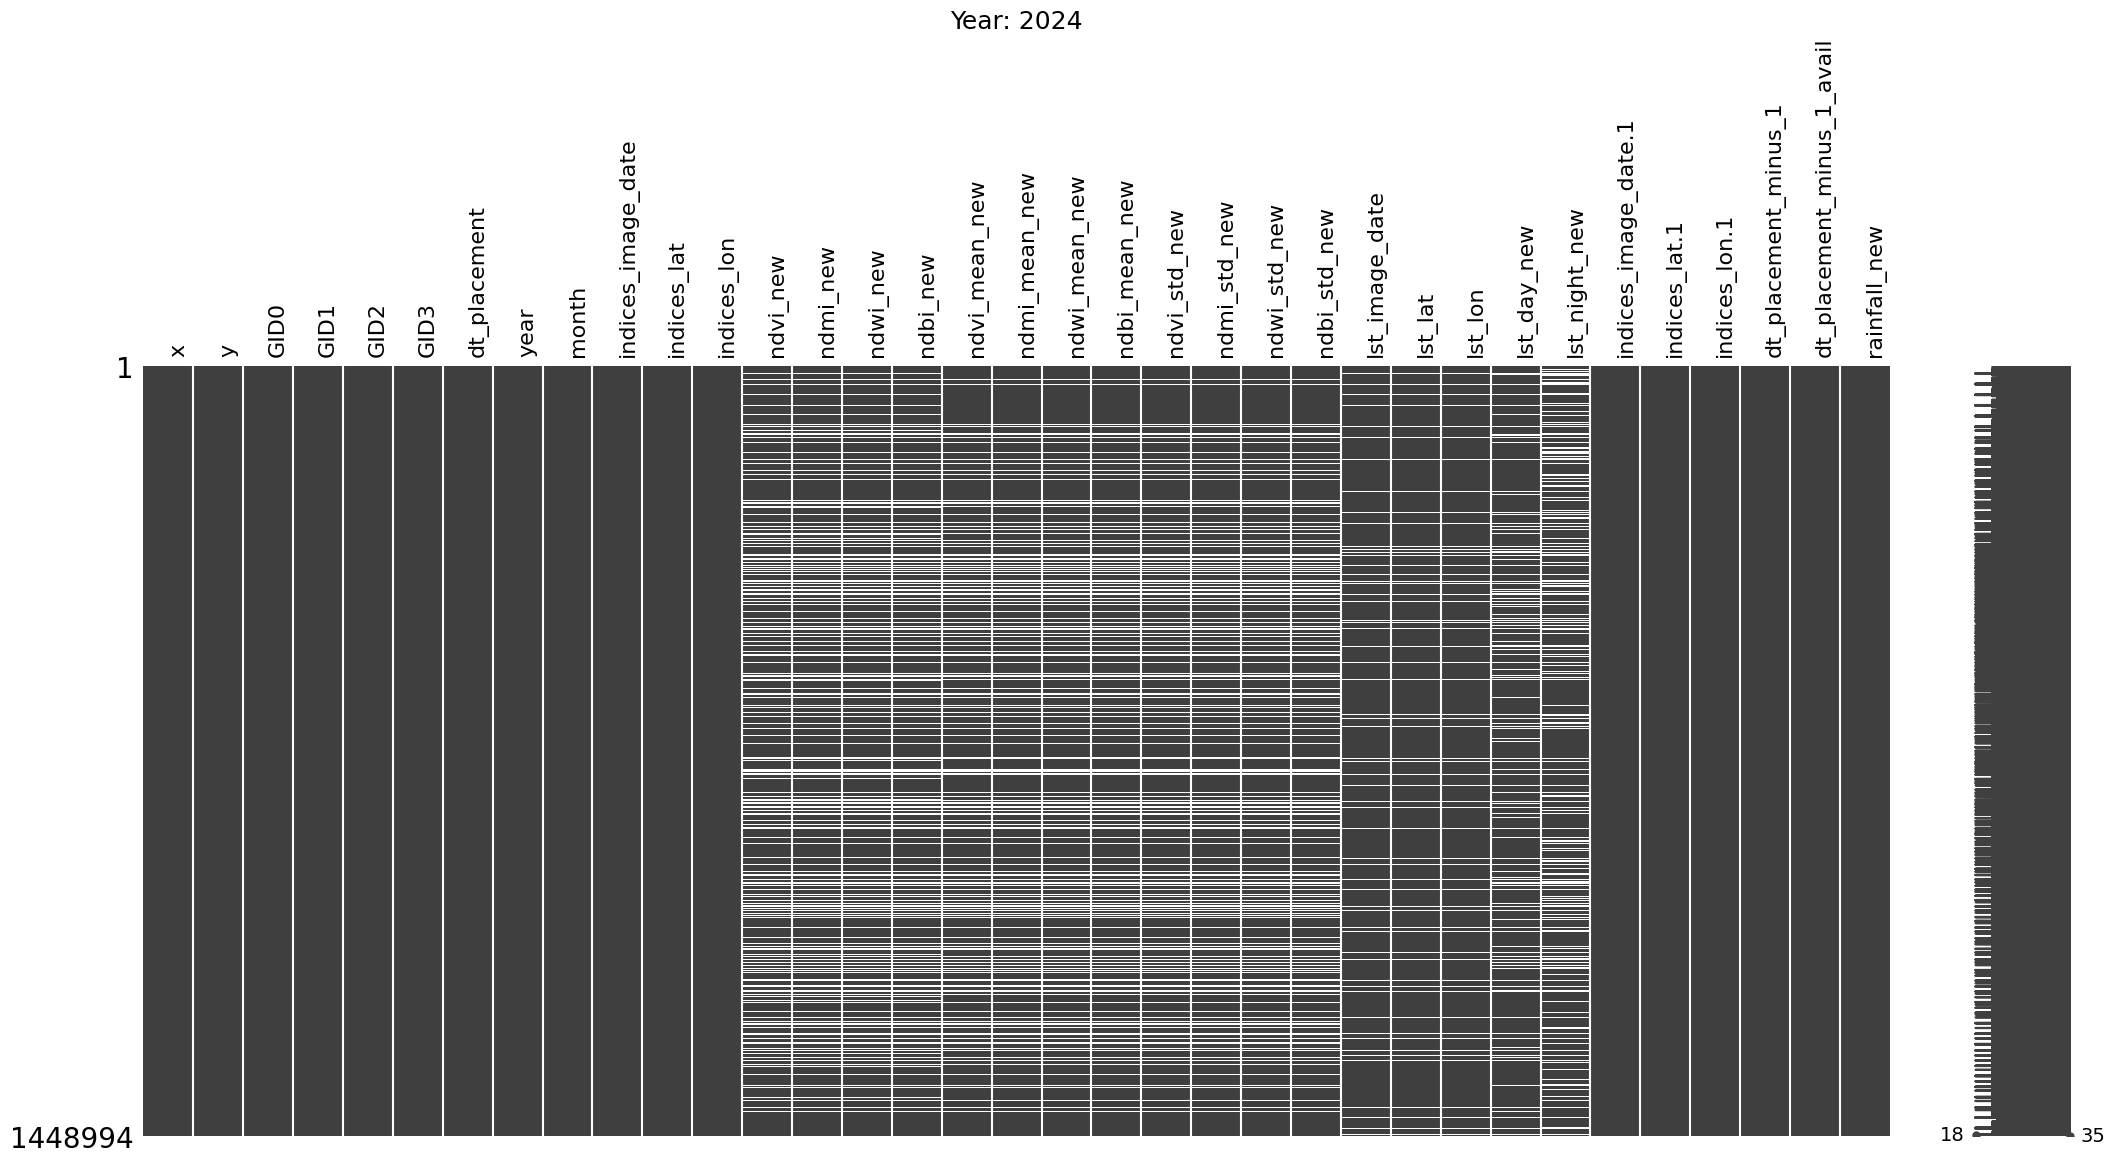

In [13]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df.year.iloc[0]}", fontsize=18)

In [14]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
12,ndvi_new,24.2549
13,ndmi_new,24.2575
14,ndwi_new,24.2549
15,ndbi_new,24.2575
16,ndvi_mean_new,20.5337
17,ndmi_mean_new,20.5355
18,ndwi_mean_new,20.5333
19,ndbi_mean_new,20.5437
20,ndvi_std_new,20.5337
21,ndmi_std_new,20.5355


In [15]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)
df = df.rename(columns=lambda x: re.sub('_new', '', x))

In [16]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
10,ndvi,24.2549
11,ndmi,24.2575
12,ndwi,24.2549
13,ndbi,24.2575
14,ndvi_mean,20.5337
15,ndmi_mean,20.5355
16,ndwi_mean,20.5333
17,ndbi_mean,20.5437
18,ndvi_std,20.5337
19,ndmi_std,20.5355


In [17]:
df2 = df.copy()

In [18]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

In [19]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
10,ndvi,24.4048
11,ndmi,24.4074
12,ndwi,24.4048
13,ndbi,24.4074
14,ndvi_mean,20.7264
15,ndmi_mean,20.7282
16,ndwi_mean,20.7260
17,ndbi_mean,20.7363
18,ndvi_std,20.7264
19,ndmi_std,20.7282


In [20]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [21]:
df2.reset_index(drop=True, inplace=True)

In [22]:
df2

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-01,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15247.0,14544.0,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-02,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15410.0,14544.0,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-03,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15410.0,14575.0,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-04,2024,1,0.234069,-0.153430,-0.298374,0.153430,0.254741,-0.141299,-0.300685,0.141299,0.024187,0.032594,0.012017,0.032594,15417.0,14521.0,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2024-01-05,2024,1,0.364624,-0.014147,-0.393515,0.014147,0.319521,-0.053684,-0.406543,0.053684,0.035530,0.029277,0.015771,0.029277,15451.0,14521.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448989,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-27,2024,12,0.254978,-0.129234,-0.289343,0.129234,0.295193,-0.097900,-0.305340,0.097900,0.086505,0.056897,0.051174,0.056897,15085.0,14441.0,0.0
1448990,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-28,2024,12,0.254978,-0.129234,-0.289343,0.129234,0.295193,-0.097900,-0.305340,0.097900,0.086505,0.056897,0.051174,0.056897,15085.0,14476.0,0.0
1448991,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-29,2024,12,0.254978,-0.129234,-0.289343,0.129234,0.295193,-0.097900,-0.305340,0.097900,0.086505,0.056897,0.051174,0.056897,15052.0,14453.0,0.0
1448992,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2024-12-30,2024,12,0.243278,-0.137847,-0.282271,0.137847,0.280358,-0.107628,-0.296999,0.107628,0.080038,0.052339,0.048076,0.052339,15157.0,14453.0,0.0


Text(0.5, 1.0, 'Year: 2024')

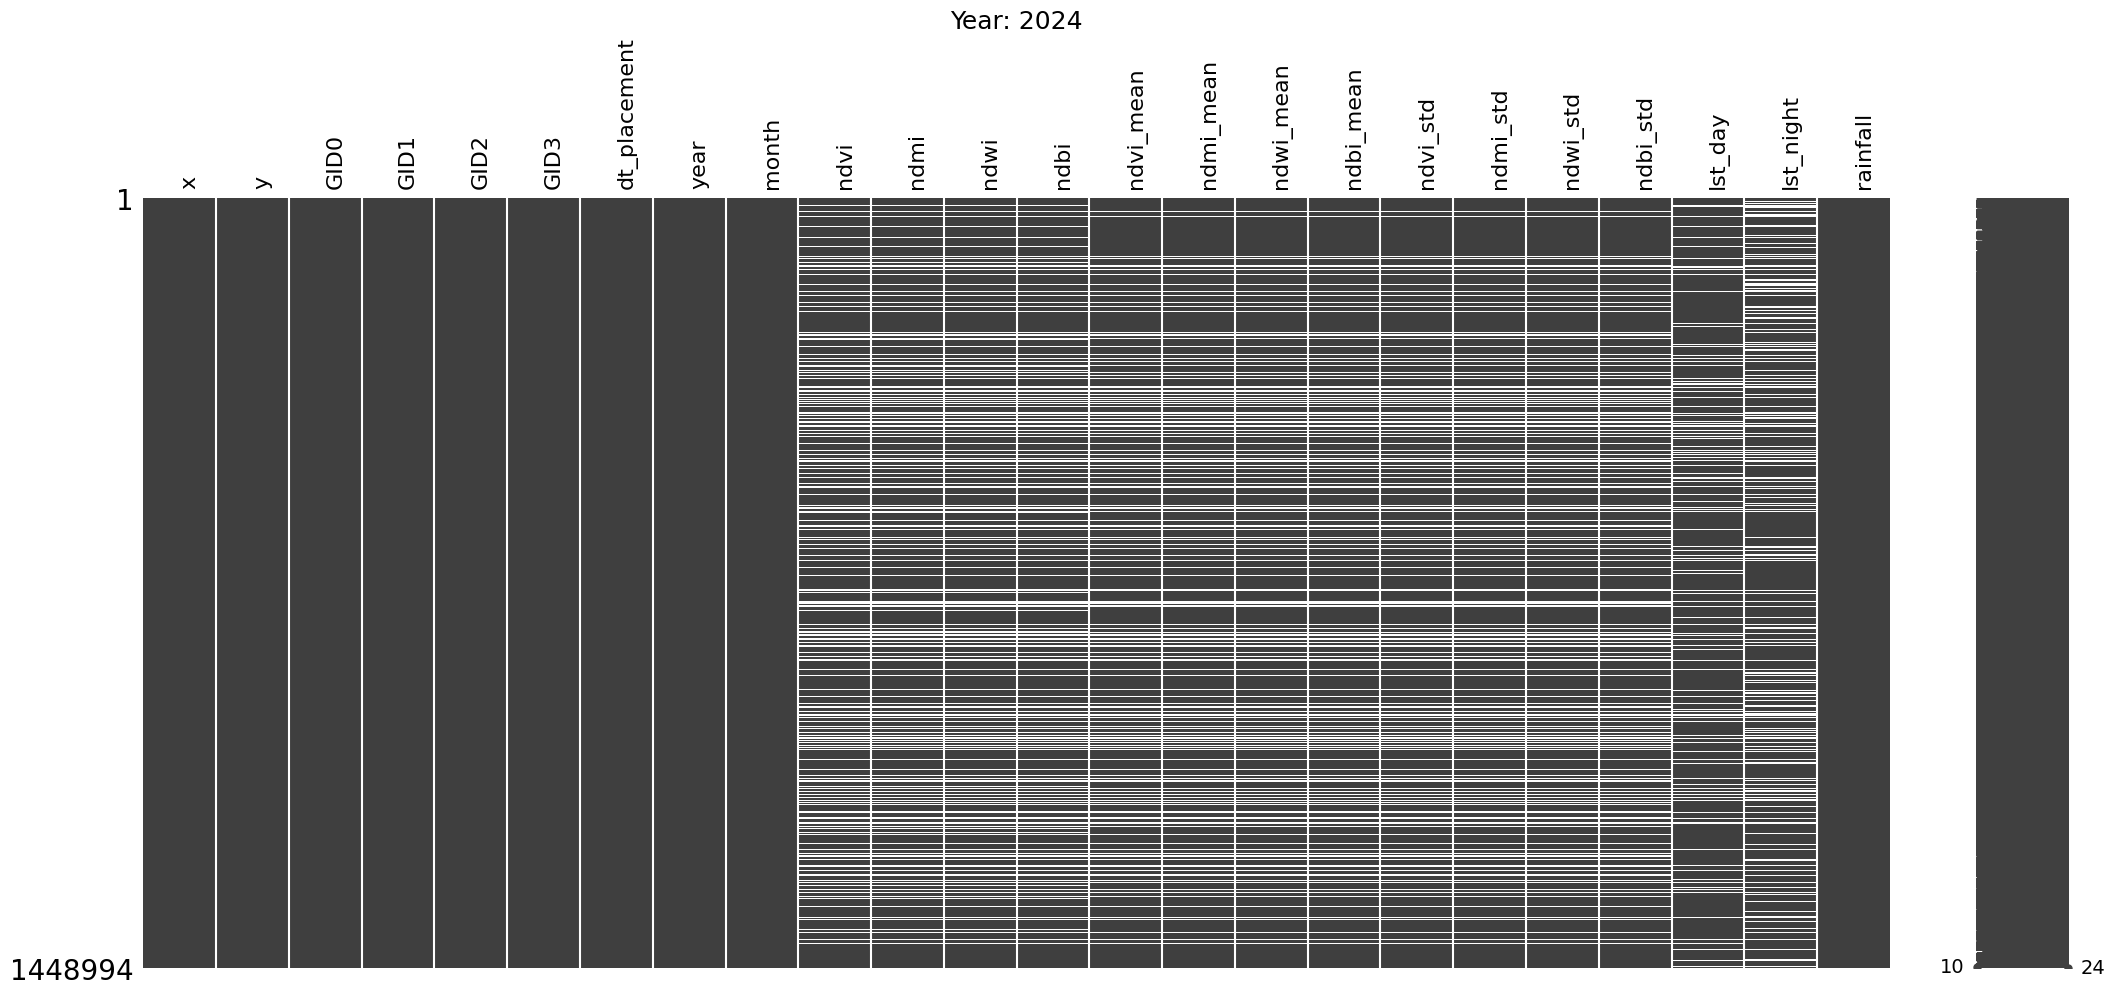

In [23]:
msno.matrix(df2, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df2.year.iloc[0]}", fontsize=18)

In [44]:
df2.to_csv(f'{base_folder}/{GID2_NAME}/CM_{GID2_NAME}_Timeline_{YEAR}_filled_cleaned.csv', encoding='utf-8', index=False)

In [45]:
df2

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-11-01,2025,11,0.412599,-0.016206,-0.398708,0.016206,0.390230,-0.044215,-0.387762,0.044215,0.021143,0.033274,0.009217,0.033274,NaN,14742.0,0.0
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-11-02,2025,11,0.412599,-0.016206,-0.398708,0.016206,0.390230,-0.044215,-0.387762,0.044215,0.021143,0.033274,0.009217,0.033274,15239.0,14585.0,0.0
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-11-03,2025,11,0.358463,-0.037755,-0.364031,0.037755,0.350199,-0.046288,-0.361641,0.046288,0.023963,0.030181,0.014918,0.030181,15239.0,14585.0,0.0
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-11-04,2025,11,0.358463,-0.037755,-0.364031,0.037755,0.350199,-0.046288,-0.361641,0.046288,0.023963,0.030181,0.014918,0.030181,15239.0,14778.0,0.0
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-11-05,2025,11,0.365103,-0.072786,-0.377608,0.072786,0.357349,-0.079874,-0.376654,0.079874,0.029671,0.033743,0.018348,0.033743,15341.0,14778.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64196,15.28186,10.24037,extreme nord,mayo-danay,yagoua,dana,2025-12-01,2025,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15165.0,14768.0,0.0
64197,15.28186,10.27630,extreme nord,mayo-danay,yagoua,dana,2025-12-01,2025,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15154.0,14832.0,0.0
64198,15.28186,10.31224,extreme nord,mayo-danay,yagoua,yagoua,2025-12-01,2025,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15119.0,14814.0,0.0
64199,15.31834,10.27630,extreme nord,mayo-danay,yagoua,dana,2025-12-01,2025,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15128.0,14754.0,0.0


In [46]:
#### Continue merging with older data

In [47]:
df_old = pd.read_csv(f'{base_folder}/{GID2_NAME}/CM_{GID2_NAME}_Timeline_2025_10_filled_cleaned.csv', encoding=enc)

In [48]:
df_old

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15339.0,NaN,0.00
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-02,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15339.0,NaN,0.11
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-03,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15299.0,14601.0,1.25
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-04,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15431.0,14619.0,0.66
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-05,2025,1,0.231400,-0.144919,-0.319074,0.144919,0.229307,-0.145684,-0.323623,0.145684,0.008093,0.013163,0.007198,0.013163,15179.0,14588.0,0.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629579,15.35483,10.24037,extreme nord,mayo-danay,yagoua,dana,2025-10-27 00:00:00,2025,10,0.520698,0.100917,-0.446558,-0.100917,0.471464,0.050157,-0.408604,-0.050157,0.039119,0.037792,0.037825,0.037792,15194.0,14852.0,0.00
629580,15.35483,10.24037,extreme nord,mayo-danay,yagoua,dana,2025-10-28 00:00:00,2025,10,0.520698,0.100917,-0.446558,-0.100917,0.471464,0.050157,-0.408604,-0.050157,0.039119,0.037792,0.037825,0.037792,15194.0,14852.0,0.00
629581,15.35483,10.24037,extreme nord,mayo-danay,yagoua,dana,2025-10-29 00:00:00,2025,10,0.520698,0.100917,-0.446558,-0.100917,0.471464,0.050157,-0.408604,-0.050157,0.039119,0.037792,0.037825,0.037792,15194.0,14852.0,0.00
629582,15.35483,10.24037,extreme nord,mayo-danay,yagoua,dana,2025-10-30 00:00:00,2025,10,0.520698,0.100917,-0.446558,-0.100917,0.471464,0.050157,-0.408604,-0.050157,0.039119,0.037792,0.037825,0.037792,15289.0,14693.0,0.00


In [49]:
df_merged = pd.concat([df_old, df2], ignore_index=True)

In [50]:
df_merged

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15339.0,NaN,0.00
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-02,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15339.0,NaN,0.11
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-03,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15299.0,14601.0,1.25
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-04,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15431.0,14619.0,0.66
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-05,2025,1,0.231400,-0.144919,-0.319074,0.144919,0.229307,-0.145684,-0.323623,0.145684,0.008093,0.013163,0.007198,0.013163,15179.0,14588.0,0.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693780,15.28186,10.24037,extreme nord,mayo-danay,yagoua,dana,2025-12-01 00:00:00,2025,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15165.0,14768.0,0.00
693781,15.28186,10.27630,extreme nord,mayo-danay,yagoua,dana,2025-12-01 00:00:00,2025,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15154.0,14832.0,0.00
693782,15.28186,10.31224,extreme nord,mayo-danay,yagoua,yagoua,2025-12-01 00:00:00,2025,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15119.0,14814.0,0.00
693783,15.31834,10.27630,extreme nord,mayo-danay,yagoua,dana,2025-12-01 00:00:00,2025,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15128.0,14754.0,0.00


In [51]:
try:
    df_merged.drop(['Unnamed: 0'], axis = 1, inplace=True)
except:
    pass

In [52]:
df_merged.to_csv(f'{base_folder}/{GID2_NAME}/CM_{GID2_NAME}_Timeline_{YEAR}_filled_cleaned.csv', encoding='utf-8', index=False)